1. Install & imports

In [1]:
!pip install -q kagglehub
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

2026-06-15 20:44:12.977877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781556253.156843      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781556253.206799      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781556253.648878      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781556253.648922      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781556253.648924      58 computation_placer.cc:177] computation placer alr

TF: 2.19.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


2. Download dataset

In [2]:
import kagglehub
path = kagglehub.dataset_download("sid321axn/beijing-multisite-airquality-data-set")
print("Path:", path)
csvs = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print(f"Found {len(csvs)} site CSV files")

Path: /kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set
Found 12 site CSV files


3. Load & merge all monitoring sites

In [3]:
# This dataset = 12 stations, one CSV each, same columns.
dfs = []
for f in csvs:
    d = pd.read_csv(f)
    dfs.append(d)
df = pd.concat(dfs, ignore_index=True)
print("Combined shape:", df.shape)
print(df.columns.tolist())
df.head()

Combined shape: (420768, 18)
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


4. Build datetime index & clean

In [4]:
# Build timestamp from year/month/day/hour columns
df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])
df = df.sort_values("datetime").reset_index(drop=True)

# Aggregate across stations to a single city-level hourly series (mean)
num_cols = ["PM2.5","PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM"]
num_cols = [c for c in num_cols if c in df.columns]
city = df.groupby("datetime")[num_cols].mean().reset_index()

# Interpolate missing sensor values (time-aware), then drop any remaining gaps
city[num_cols] = city[num_cols].interpolate(method="linear", limit_direction="both")
city = city.dropna().reset_index(drop=True)
print("City-level shape:", city.shape)
city.head()

City-level shape: (35064, 12)


,datetime,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
0,2013-03-01 00:00:00,5.666667,7.916667,5.666667,12.600000,308.333333,75.416667,-0.916667,1022.766667,-19.900000,0.0,4.175000
1,2013-03-01 01:00:00,6.833333,9.833333,5.333333,13.111111,308.333333,75.750000,-1.216667,1023.191667,-19.916667,0.0,3.875000
2,2013-03-01 02:00:00,5.666667,7.250000,8.166667,12.900000,300.000000,66.000000,-1.591667,1023.325000,-21.008333,0.0,4.400000
3,2013-03-01 03:00:00,6.000000,9.250000,5.833333,12.400000,283.333333,75.333333,-1.891667,1024.208333,-21.833333,0.0,3.366667
4,2013-03-01 04:00:00,4.833333,6.916667,6.750000,14.000000,308.333333,66.333333,-2.283333,1024.866667,-21.625000,0.0,2.716667


5. Feature engineering (time features)

In [5]:
# Cyclical time encodings help the model learn daily/seasonal patterns
city["hour"]  = city["datetime"].dt.hour
city["month"] = city["datetime"].dt.month
city["hour_sin"]  = np.sin(2*np.pi*city["hour"]/24)
city["hour_cos"]  = np.cos(2*np.pi*city["hour"]/24)
city["mon_sin"]   = np.sin(2*np.pi*city["month"]/12)
city["mon_cos"]   = np.cos(2*np.pi*city["month"]/12)

feature_cols = [c for c in num_cols if c != "PM2.5"] + \
               ["hour_sin","hour_cos","mon_sin","mon_cos","PM2.5"]
target_col = "PM2.5"
data = city[feature_cols].values
print("Feature matrix:", data.shape, "| Target = PM2.5 (last column)")

Feature matrix: (35064, 15) | Target = PM2.5 (last column)


6. Scale + chronological split (no shuffling for time series)

In [6]:
# Split BEFORE scaling fit to avoid leakage
n = len(data)
train_end = int(n*0.8)

scaler = MinMaxScaler()
train_raw = data[:train_end]
test_raw  = data[train_end:]

scaler.fit(train_raw)                 # fit on train only
train_scaled = scaler.transform(train_raw)
test_scaled  = scaler.transform(test_raw)
target_idx = feature_cols.index(target_col)

7. Windowing (last 24h → predict next hour PM2.5)

In [7]:
LOOKBACK = 24
def make_sequences(arr, lookback, tgt_idx):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i-lookback:i, :])
        y.append(arr[i, tgt_idx])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_scaled, LOOKBACK, target_idx)
X_test,  y_test  = make_sequences(test_scaled,  LOOKBACK, target_idx)
print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (28027, 24, 15) X_test: (6989, 24, 15)


8. Build the LSTM model

In [8]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)                          # regression output
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

I0000 00:00:1781556485.000905      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781556485.006924      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,441 (130.63 KB)

 Trainable params: 33,441 (130.63 KB)

 Non-trainable params: 0 (0.00 B)

9. Train: 100 epochs + early stopping

In [9]:
early = EarlyStopping(monitor="val_loss", patience=10,
                      restore_best_weights=True, verbose=1)
ckpt  = ModelCheckpoint("/kaggle/working/best_lstm.keras",
                        monitor="val_loss", save_best_only=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100, batch_size=64,
    callbacks=[early, ckpt],
    verbose=1
)

Epoch 1/100


I0000 00:00:1781556493.478490     152 cuda_dnn.cc:529] Loaded cuDNN version 91002


395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0029 - mae: 0.0366 - val_loss: 0.0020 - val_mae: 0.0252
Epoch 2/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0013 - mae: 0.0248 - val_loss: 0.0011 - val_mae: 0.0179
Epoch 3/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 8.8348e-04 - mae: 0.0204 - val_loss: 7.6937e-04 - val_mae: 0.0147
Epoch 4/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.7585e-04 - mae: 0.0180 - val_loss: 6.3486e-04 - val_mae: 0.0133
Epoch 5/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5.6460e-04 - mae: 0.0162 - val_loss: 5.7290e-04 - val_mae: 0.0137
Epoch 6/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 4.8089e-04 - mae: 0.0150 - val_loss: 5.0516e-04 - val_mae: 0.0124
Epoch 7/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4.2010e-04 - mae: 0.0141 - val_loss: 4.6500e-04 - val_mae: 0.0116
Epoch 8/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.7460e-04 - mae: 0.0131 - val_loss: 4.0956e-04 - val_mae: 0.0110
Epoch 9/100


10. Evaluate (inverse-scale back to real PM2.5 µg/m³)

In [10]:
pred_scaled = model.predict(X_test).flatten()

# Inverse-transform only the target column
def inverse_target(scaled_vals):
    tmp = np.zeros((len(scaled_vals), len(feature_cols)))
    tmp[:, target_idx] = scaled_vals
    return scaler.inverse_transform(tmp)[:, target_idx]

y_pred = inverse_target(pred_scaled)
y_true = inverse_target(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
print(f"RMSE: {rmse:.2f} µg/m³")
print(f"MAE : {mae:.2f} µg/m³")
print(f"R²  : {r2:.4f}")

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
RMSE: 10.10 µg/m³
MAE : 6.22 µg/m³
R²  : 0.9833


11. Plots: training curve + predicted vs actual

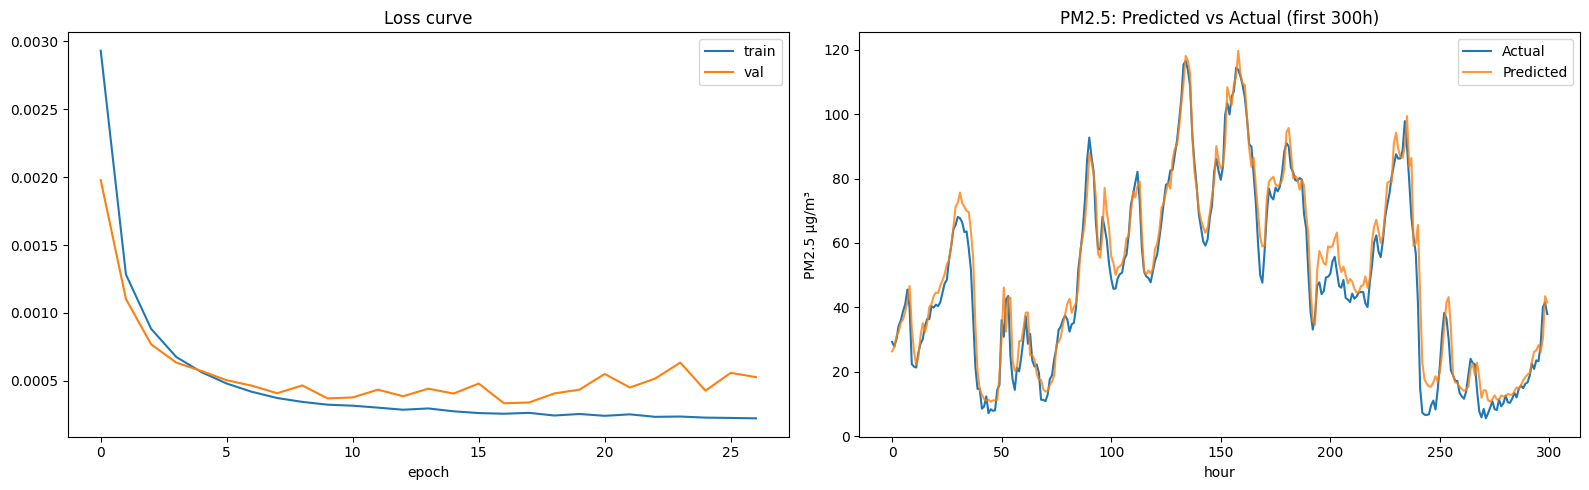

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))
ax[0].plot(history.history["loss"], label="train")
ax[0].plot(history.history["val_loss"], label="val")
ax[0].set_title("Loss curve"); ax[0].set_xlabel("epoch"); ax[0].legend()

ax[1].plot(y_true[:300], label="Actual")
ax[1].plot(y_pred[:300], label="Predicted", alpha=0.8)
ax[1].set_title("PM2.5: Predicted vs Actual (first 300h)")
ax[1].set_xlabel("hour"); ax[1].set_ylabel("PM2.5 µg/m³"); ax[1].legend()
plt.tight_layout(); plt.show()

12. Save artifacts

In [12]:
import joblib
model.save("/kaggle/working/pm25_lstm.keras")
joblib.dump(scaler, "/kaggle/working/scaler.pkl")
print("Saved model + scaler — download from Output panel.")

Saved model + scaler — download from Output panel.
